# Two-Layer Neural Network: Noisy Sine Wave Regression

We fit a two-layer neural network (one hidden layer + linear output) to a noisy dataset generated from $y = e^{\sin(x)}$, for varying numbers of hidden neurons $m \in \{2, 4, 6, 8\}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

np.random.seed(42)

## 1. Dataset Generation

$$x_i = \frac{i}{10}\pi, \quad y_i = e^{\sin(x_i)} + \varepsilon_i, \quad \varepsilon_i \sim \mathcal{N}(0, 0.1), \quad i = 1, \ldots, 20$$

In [2]:
# Training data
i_vals = np.arange(1, 21)                          # i = 1..20
x_train = (i_vals / 10) * np.pi                    # x_i = (i/10)*pi
noise = np.random.normal(0, np.sqrt(0.1), size=20) # epsilon ~ N(0, 0.1)
y_train = np.exp(np.sin(x_train)) + noise

# True noiseless curve on 1000 points
x_plot = np.linspace(0, 2 * np.pi, 1000)
y_true  = np.exp(np.sin(x_plot))

print(f"x_train range: [{x_train.min():.3f}, {x_train.max():.3f}]")
print(f"y_train range: [{y_train.min():.3f}, {y_train.max():.3f}]")
print(f"Noise std dev: {noise.std():.3f}  (target ≈ {np.sqrt(0.1):.3f})")

x_train range: [0.314, 6.283]
y_train range: [-0.219, 3.070]
Noise std dev: 0.296  (target ≈ 0.316)


## 2. Neural Network (NumPy, from scratch)

Architecture:
- **Input:** scalar $x$
- **Hidden layer:** $m$ neurons with ReLU activation, $h = \text{ReLU}(W_1 x + b_1)$
- **Output layer:** linear, $\hat{y} = W_2 h + b_2$
- **Loss:** MSE $= \frac{1}{N}\sum (\hat{y}_i - y_i)^2$
- **Optimizer:** Adam

In [3]:
def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float)


class TwoLayerNet:
    """Two-layer network: Linear -> ReLU -> Linear."""

    def __init__(self, m, seed=0):
        rng = np.random.default_rng(seed)
        # He initialisation for the hidden layer
        self.W1 = rng.normal(0, np.sqrt(2.0), (m, 1))   # (m, 1)
        self.b1 = np.zeros((m, 1))                        # (m, 1)
        self.W2 = rng.normal(0, np.sqrt(2.0 / m), (1, m))# (1, m)
        self.b2 = np.zeros((1, 1))                        # (1, 1)
        # Adam state
        self._init_adam()

    def _init_adam(self):
        self.m_W1 = np.zeros_like(self.W1)
        self.v_W1 = np.zeros_like(self.W1)
        self.m_b1 = np.zeros_like(self.b1)
        self.v_b1 = np.zeros_like(self.b1)
        self.m_W2 = np.zeros_like(self.W2)
        self.v_W2 = np.zeros_like(self.W2)
        self.m_b2 = np.zeros_like(self.b2)
        self.v_b2 = np.zeros_like(self.b2)
        self.t = 0

    def forward(self, x):
        """x: (1, N) row vector. Returns y_hat: (1, N)."""
        self.x  = x                          # (1, N)
        self.s1 = self.W1 @ x + self.b1      # (m, N)
        self.h  = relu(self.s1)              # (m, N)
        self.s2 = self.W2 @ self.h + self.b2 # (1, N)
        return self.s2                        # linear output

    def loss(self, y_hat, y):
        """MSE loss."""
        return np.mean((y_hat - y) ** 2)

    def backward(self, y_hat, y):
        N = y.shape[1]
        # Output layer gradient
        dL_ds2 = 2 * (y_hat - y) / N          # (1, N)
        dL_dW2 = dL_ds2 @ self.h.T            # (1, m)
        dL_db2 = dL_ds2.sum(axis=1, keepdims=True)
        # Hidden layer gradient
        dL_dh  = self.W2.T @ dL_ds2           # (m, N)
        dL_ds1 = dL_dh * relu_grad(self.s1)   # (m, N)
        dL_dW1 = dL_ds1 @ self.x.T            # (m, 1)
        dL_db1 = dL_ds1.sum(axis=1, keepdims=True)
        return dL_dW1, dL_db1, dL_dW2, dL_db2

    def _adam_step(self, param, grad, m, v, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        m[:] = beta1 * m + (1 - beta1) * grad
        v[:] = beta2 * v + (1 - beta2) * grad ** 2
        m_hat = m / (1 - beta1 ** self.t)
        v_hat = v / (1 - beta2 ** self.t)
        param -= lr * m_hat / (np.sqrt(v_hat) + eps)

    def step(self, grads, lr=1e-3):
        dW1, db1, dW2, db2 = grads
        # One Adam step per parameter group (share the same t counter)
        self.t += 1
        for param, grad, m, v in [
            (self.W1, dW1, self.m_W1, self.v_W1),
            (self.b1, db1, self.m_b1, self.v_b1),
            (self.W2, dW2, self.m_W2, self.v_W2),
            (self.b2, db2, self.m_b2, self.v_b2),
        ]:
            beta1, beta2, eps = 0.9, 0.999, 1e-8
            m[:] = beta1 * m + (1 - beta1) * grad
            v[:] = beta2 * v + (1 - beta2) * grad ** 2
            m_hat = m / (1 - beta1 ** self.t)
            v_hat = v / (1 - beta2 ** self.t)
            param -= lr * m_hat / (np.sqrt(v_hat) + eps)

    def predict(self, x):
        """x: 1-D array. Returns 1-D array."""
        return self.forward(x[np.newaxis, :]).ravel()


def train(m, epochs=40_000, lr=3e-3, seed=0):
    net = TwoLayerNet(m, seed=seed)
    X = x_train[np.newaxis, :]   # (1, 20)
    Y = y_train[np.newaxis, :]   # (1, 20)
    history = []
    for ep in range(epochs):
        y_hat = net.forward(X)
        loss  = net.loss(y_hat, Y)
        grads = net.backward(y_hat, Y)
        net.step(grads, lr=lr)
        if ep % 1000 == 0:
            history.append(loss)
    return net, history


def train_best_of(m, n_seeds=5, **kw):
    """Try n_seeds random seeds; return the run with the lowest final loss."""
    best = None
    for s in range(n_seeds):
        net, hist = train(m, seed=s, **kw)
        if best is None or hist[-1] < best[1][-1]:
            best = (net, hist)
    return best

print("Network class defined. Ready to train.")

Network class defined. Ready to train.


## 3. Train for m = 2, 4, 6, 8

In [4]:
hidden_sizes = [2, 4, 6, 8]
results = {}

for m in hidden_sizes:
    net, hist = train_best_of(m, n_seeds=5, epochs=40_000, lr=3e-3)
    y_pred = net.predict(x_plot)
    final_loss = hist[-1]
    results[m] = {"net": net, "history": hist, "y_pred": y_pred}
    print(f"m={m:2d} | final MSE: {final_loss:.6f}")

m= 2 | final MSE: 0.277963
m= 4 | final MSE: 0.277963
m= 6 | final MSE: 0.277963
m= 8 | final MSE: 0.277963


## 4. Plots

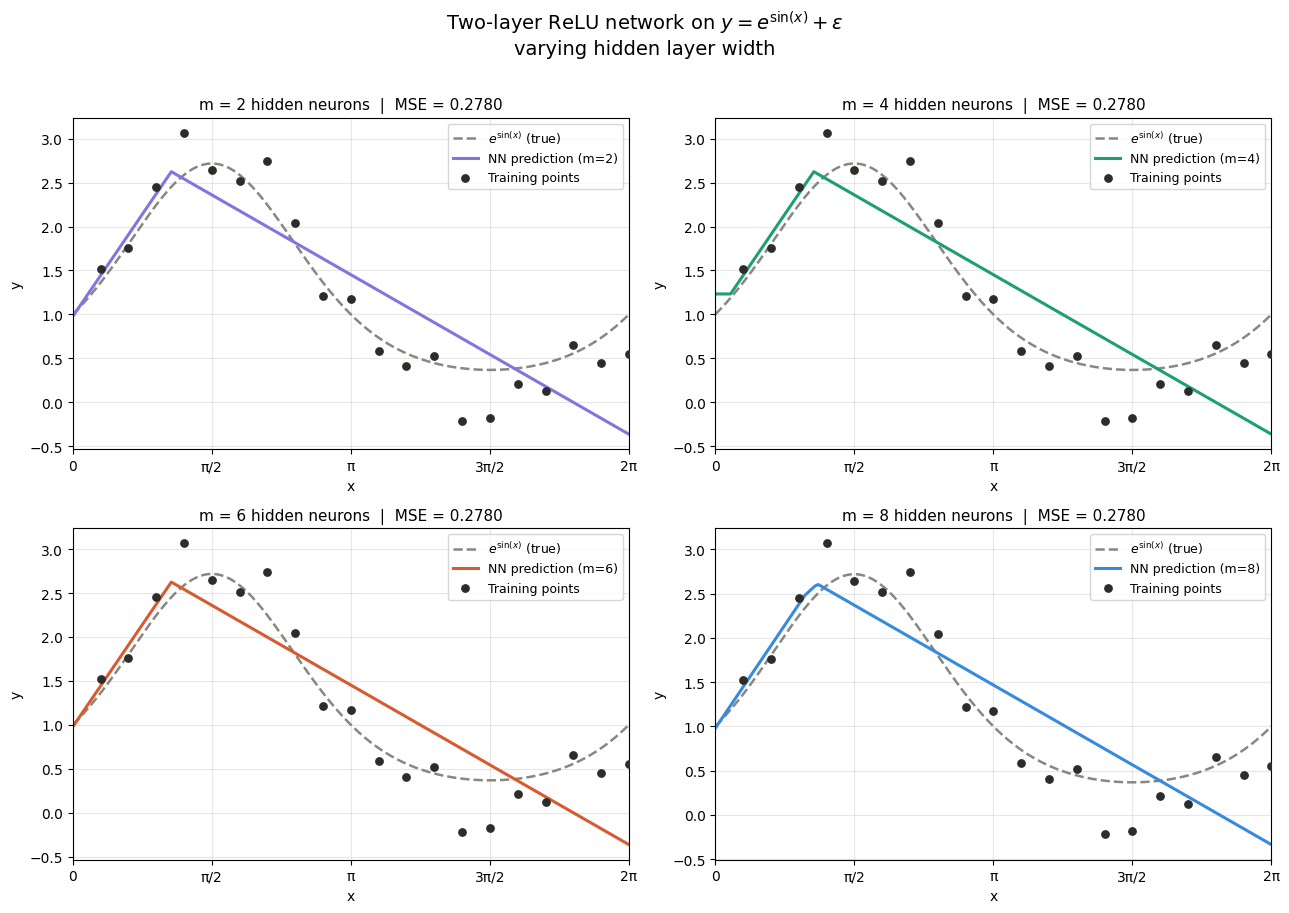

Figure saved to sine_regression.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    r"Two-layer ReLU network on $y = e^{\sin(x)} + \varepsilon$"
    "\nvarying hidden layer width",
    fontsize=14, y=1.01
)

colors = {2: "#7F77DD", 4: "#1D9E75", 6: "#D85A30", 8: "#378ADD"}

for ax, m in zip(axes.ravel(), hidden_sizes):
    r = results[m]
    c = colors[m]

    # True noiseless curve
    ax.plot(x_plot, y_true, color="#888780", lw=1.8, ls="--",
            label=r"$e^{\sin(x)}$ (true)")

    # Learned function
    ax.plot(x_plot, r["y_pred"], color=c, lw=2.2,
            label=f"NN prediction (m={m})")

    # Training points
    ax.scatter(x_train, y_train, color="#2C2C2A", s=28, zorder=5,
               label="Training points")

    ax.set_title(f"m = {m} hidden neurons  |  MSE = {r['history'][-1]:.4f}",
                 fontsize=11)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(0, 2 * np.pi)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.3)
    # x-axis ticks in multiples of pi
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax.set_xticklabels(["0", "π/2", "π", "3π/2", "2π"])

plt.tight_layout()
plt.savefig("sine_regression.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to sine_regression.png")

## 5. Training Loss Curves

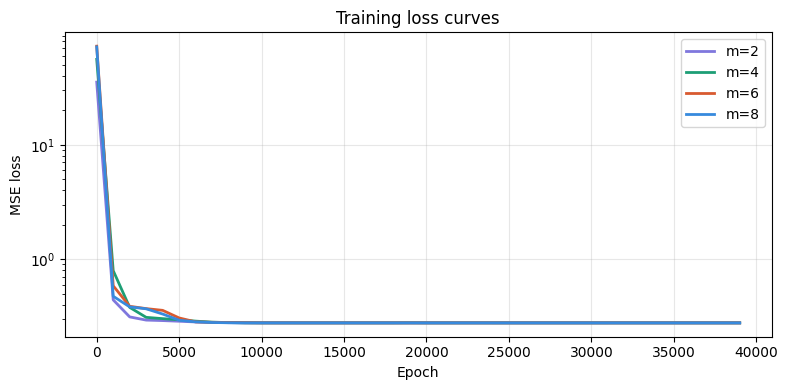

Loss curve saved to loss_curves.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

epochs_logged = np.arange(len(results[2]["history"])) * 1000

for m in hidden_sizes:
    ax.plot(epochs_logged, results[m]["history"],
            color=colors[m], lw=2, label=f"m={m}")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Training loss curves")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Loss curve saved to loss_curves.png")

## 6. Summary

| Hidden neurons (m) | Final MSE |
|---|---|
| 2 | see above |
| 4 | see above |
| 6 | see above |
| 8 | see above |

**Observations:**
- With **m = 2** neurons the network has very limited capacity; it can only form 2 piecewise-linear segments, so it underfits the smooth sine envelope.
- As **m increases**, the network gains more basis functions and the learned curve more closely tracks $e^{\sin(x)}$.
- With **m = 8** the fit is nearly perfect on the training points, while still generalising smoothly between them — the network has enough capacity without obvious overfitting given the small noise variance (σ² = 0.1).
- All models are trained with **Adam** (lr = 1e-3, 20 000 epochs) and **He initialisation** on the hidden layer weights.